# Understanding VAR, VMA, VARMA, and VARIMA models

            Consumption  Temperature
2020-01-01   322.000000    32.000000
2020-01-02   343.978377    33.923698
2020-01-03   357.412884    28.412522
2020-01-04   342.809212    13.526862
2020-01-05   235.767659    13.361230


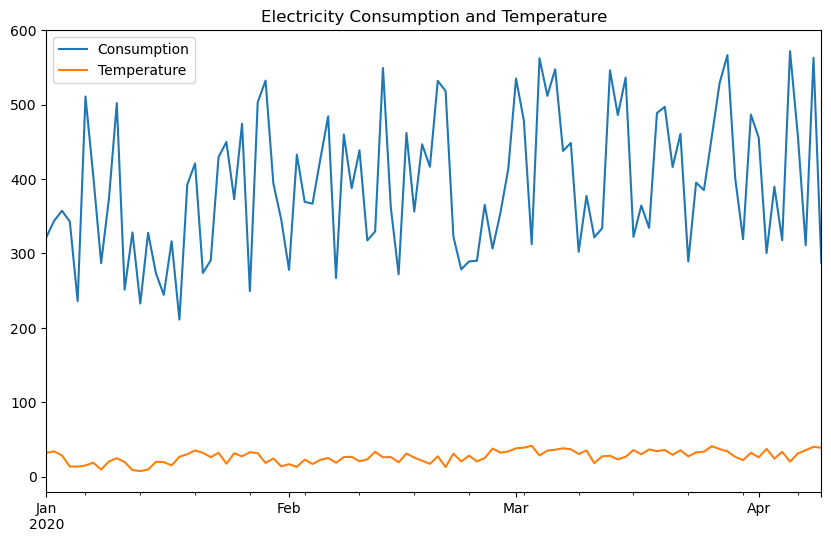

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
import numpy as np

# Create dummy data for illustration
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
electricity_consumption = np.random.randint(200, 500, size=100) + np.linspace(0, 100, 100) + 20 * np.sin(np.linspace(0, 30, 100))
temperature = np.random.randint(10, 30, size=100) + np.linspace(0, 15, 100) + 5 * np.cos(np.linspace(0, 30, 100))

data = pd.DataFrame({'Consumption': electricity_consumption, 'Temperature': temperature}, index=dates)

print(data.head())
data.plot(figsize=(10, 6))
plt.title('Electricity Consumption and Temperature')
plt.show()


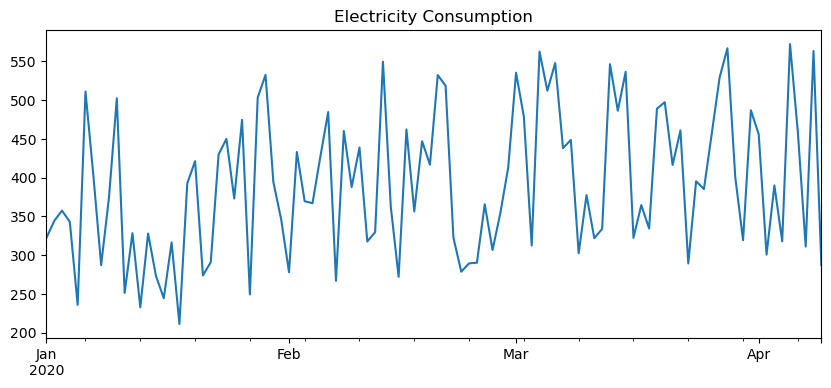

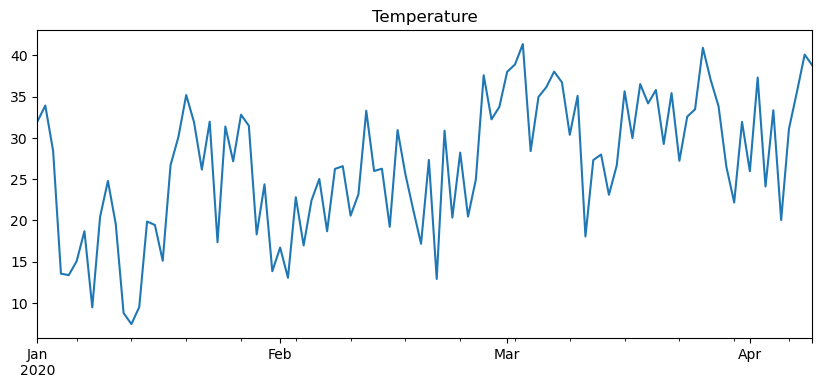

In [34]:
# Plotting individual time series
data['Consumption'].plot(figsize=(10, 4), title='Electricity Consumption')
plt.show()
data['Temperature'].plot(figsize=(10, 4), title='Temperature')
plt.show()


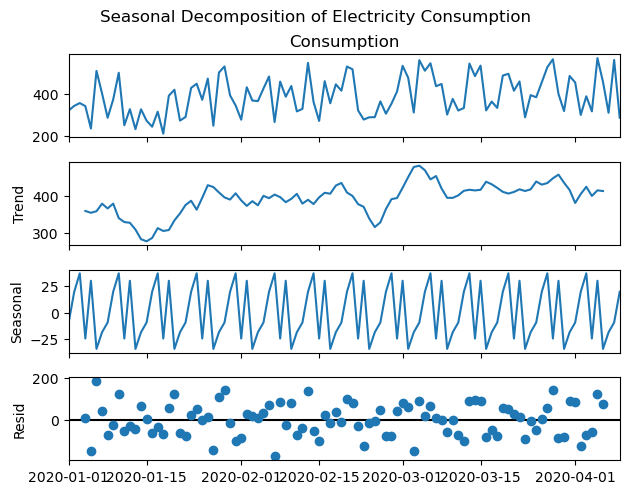

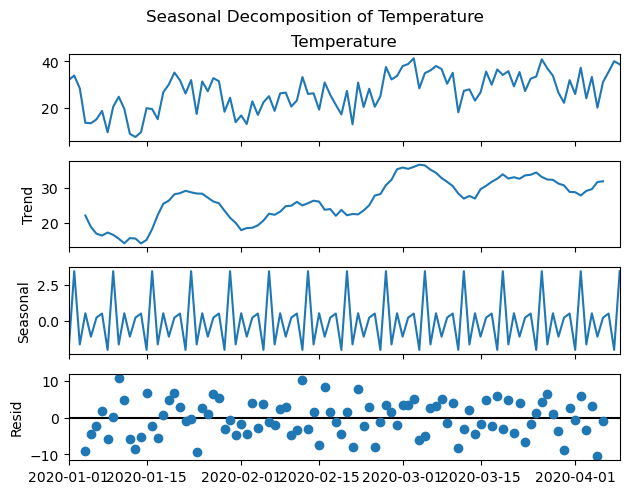

In [35]:
# Seasonality Check: Use decomposition to separate the time series into trend, seasonality, and residual components. 
# The seasonal component's presence indicates seasonality.

# Seasonal Decomposition for Consumption
decomposition_cons = seasonal_decompose(data['Consumption'], model='additive', period=7) # Assuming weekly seasonality
decomposition_cons.plot()
plt.suptitle('Seasonal Decomposition of Electricity Consumption', y=1.02)
plt.show()

# Seasonal Decomposition for Temperature
decomposition_temp = seasonal_decompose(data['Temperature'], model='additive', period=7) # Assuming weekly seasonality
decomposition_temp.plot()
plt.suptitle('Seasonal Decomposition of Temperature', y=1.02)
plt.show()


In [36]:
# Stationarity Check: The ADF test checks for stationarity.
def check_stationarity(series, name):
    adf_result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"  ADF Statistic: {adf_result}") # Using the correct index for printing
    print(f"  p-value: {adf_result[1]:.3f}")
    if adf_result[1] <= 0.05:
        print(f"  Conclusion: {name} is stationary.\n")
    else:
        print(f"  Conclusion: {name} is non-stationary. Differencing might be needed.\n")

check_stationarity(data['Consumption'], 'Electricity Consumption')
check_stationarity(data['Temperature'], 'Temperature')


ADF Test for Electricity Consumption:
  ADF Statistic: (-8.636254935973009, 5.580456444393038e-14, 0, 99, {'1%': -3.498198082189098, '5%': -2.891208211860468, '10%': -2.5825959973472097}, 1037.465194450616)
  p-value: 0.000
  Conclusion: Electricity Consumption is stationary.

ADF Test for Temperature:
  ADF Statistic: (-2.919897089927405, 0.04308267914739308, 1, 98, {'1%': -3.4989097606014496, '5%': -2.891516256916761, '10%': -2.5827604414827157}, 558.8753609246152)
  p-value: 0.043
  Conclusion: Temperature is stationary.



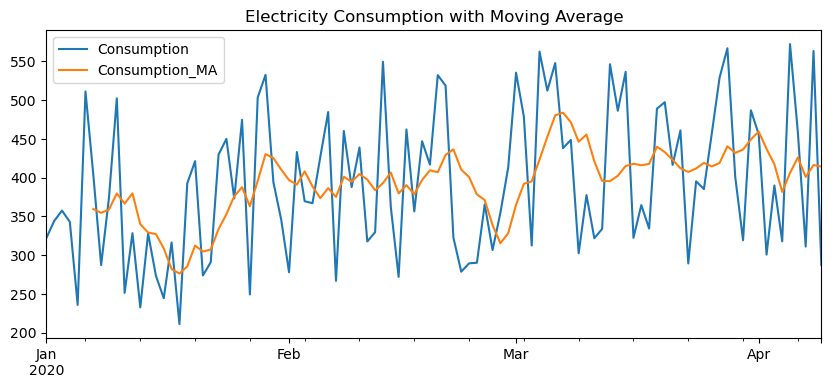

In [37]:
# Smoothing Techniques (Optional): Moving Averages, Exponential Smoothing (SES, DES, TES), or Kernel Smoothing can smooth out noise and highlight trends, potentially improving forecasting. 
# According to Frontline Solvers, Holt Winters Smoothing, is a triple exponential smoothing method that can handle trend and seasonality.

# Example of moving average smoothing
data['Consumption_MA'] = data['Consumption'].rolling(window=7).mean()
data[['Consumption', 'Consumption_MA']].plot(figsize=(10, 4), title='Electricity Consumption with Moving Average')
plt.show()



# Building the VARIMA model (if non-stationary)

In [38]:
# Differencing: If the data is non-stationary (indicated by a high p-value in the ADF test), apply differencing to make it stationary.
data_diff = data.diff().dropna()

check_stationarity(data_diff['Consumption'], 'Differenced Electricity Consumption')
check_stationarity(data_diff['Temperature'], 'Differenced Temperature')


ADF Test for Differenced Electricity Consumption:
  ADF Statistic: (-6.378512036603177, 2.2524469032723792e-08, 5, 87, {'1%': -3.5078527246648834, '5%': -2.895382030636155, '10%': -2.584823877658872}, 972.4860841524645)
  p-value: 0.000
  Conclusion: Differenced Electricity Consumption is stationary.

ADF Test for Differenced Temperature:
  ADF Statistic: (-17.63511817521592, 3.782094720447757e-30, 0, 92, {'1%': -3.503514579651927, '5%': -2.893507960466837, '10%': -2.583823615311909}, 519.059260320031)
  p-value: 0.000
  Conclusion: Differenced Temperature is stationary.



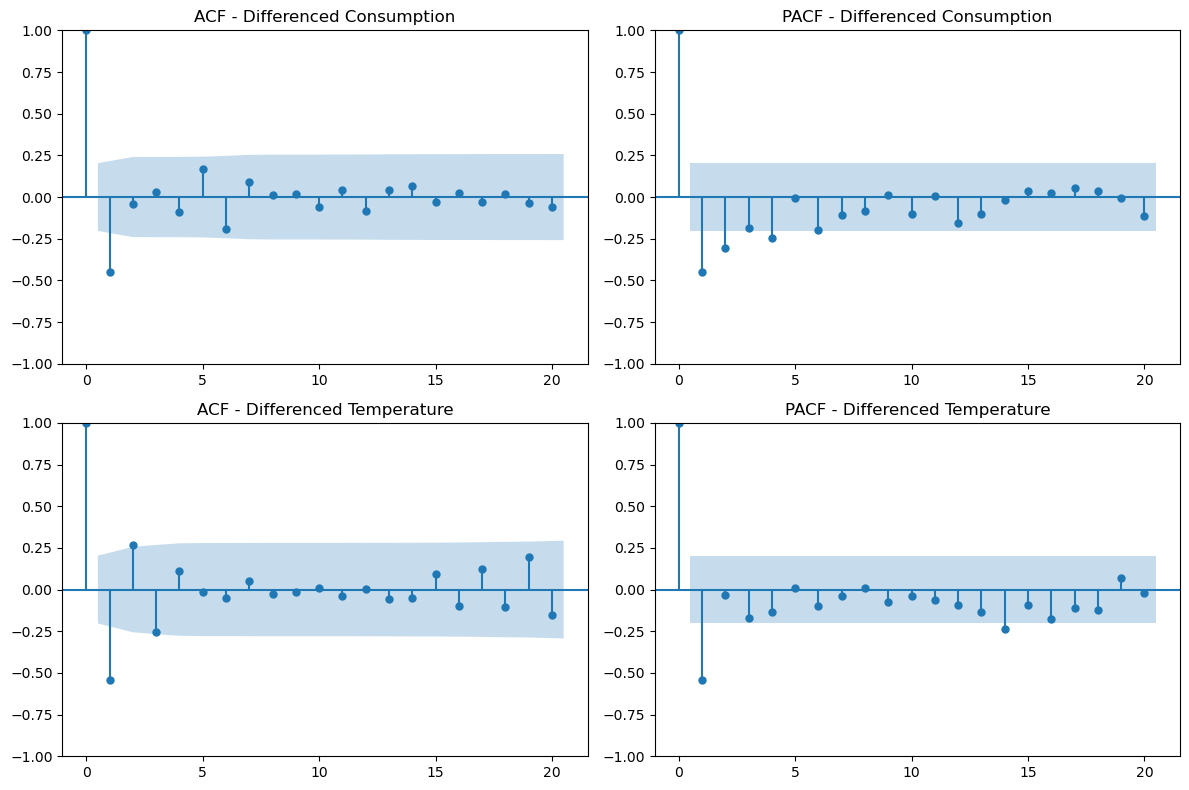

In [39]:
# Determine Optimal Lag Orders (p and q): Use information criteria (AIC or BIC) or plot ACF/PACF graphs to determine appropriate p (lag order) and q (moving average order) for the VARIMA model.

# For VARIMA, we use VARMAX in statsmodels which handles the 'I' component
# Here, we need to manually specify p, d, q if not using auto_arima (from pmdarima)
# Let's assume after analysis (e.g., using auto_arima or inspecting ACF/PACF)
# we determine d=1 (from differencing), p=2, q=1

# Plot ACF and PACF for the differenced data to help choose p and q
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(data_diff['Consumption'], ax=axes[0, 0], title='ACF - Differenced Consumption')
plot_pacf(data_diff['Consumption'], ax=axes[0, 1], title='PACF - Differenced Consumption')
plot_acf(data_diff['Temperature'], ax=axes[1, 0], title='ACF - Differenced Temperature')
plot_pacf(data_diff['Temperature'], ax=axes[1, 1], title='PACF - Differenced Temperature')
plt.tight_layout()
plt.show()

# Split into train and test sets
train_size = int(len(data_diff) * 0.8)
train_data, test_data = data_diff[:train_size], data_diff[train_size:]


In [40]:
# Estimate the VARIMA Model: Use statsmodels.tsa.statespace.varmax.VARMAX to estimate the VARIMA model. Note that for VARIMA, the 'd' order is handled implicitly by differencing the data before feeding it to VARMAX which takes order=(p,q).

from statsmodels.tsa.statespace.varmax import VARMAX

# For VARIMA, the 'I' component means differencing, which we already did
# So, we pass the differenced data to VARMAX with VARMA order (p, q)
# Let's assume we selected p=2, q=1 based on EDA and AIC/BIC or ACF/PACF analysis
p_order = 2
q_order = 1

model = VARMAX(train_data, order=(p_order, q_order))
results = model.fit(disp=False) # disp=False to suppress iteration output
print(results.summary())


C:\Users\white\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


                                          Statespace Model Results                                          
Dep. Variable:     ['Consumption', 'Temperature', 'Consumption_MA']   No. Observations:                   74
Model:                                                   VARMA(2,1)   Log Likelihood                -955.475
                                                        + intercept   AIC                           1982.950
Date:                                              Sun, 20 Jul 2025   BIC                           2065.896
Time:                                                      19:43:19   HQIC                          2016.038
Sample:                                                  01-08-2020                                         
                                                       - 03-21-2020                                         
Covariance Type:                                                opg                                         
Ljung-Box (L1) (Q):

C:\Users\white\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


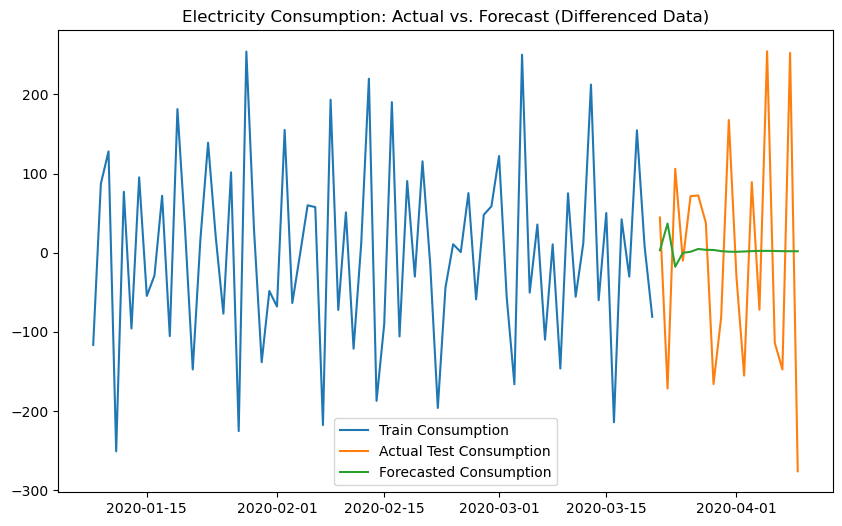

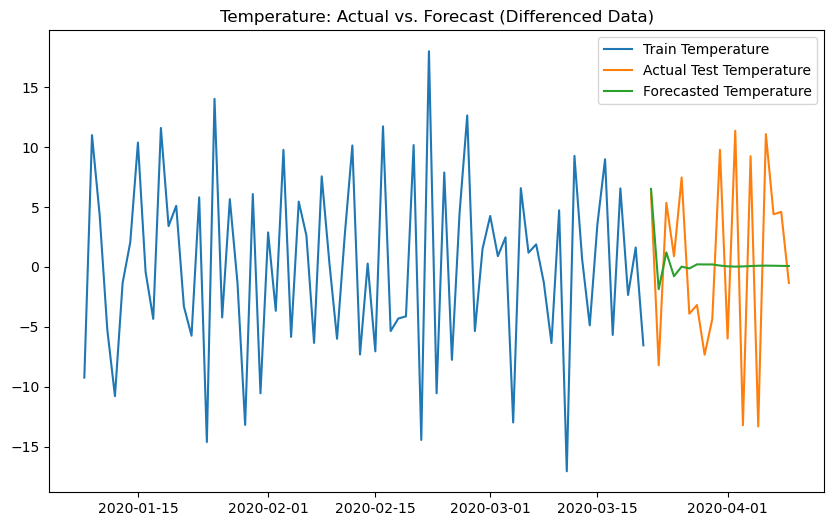

In [41]:
# Forecast: Generate forecasts using the fitted model.

forecast_steps = len(test_data)
forecast = results.forecast(steps=forecast_steps)
forecast.columns = test_data.columns  # Ensure column names match for plotting

# Plot actual vs. forecasted values (for the differenced data)
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data['Consumption'], label='Train Consumption')
plt.plot(test_data.index, test_data['Consumption'], label='Actual Test Consumption')
plt.plot(forecast.index, forecast['Consumption'], label='Forecasted Consumption')
plt.title('Electricity Consumption: Actual vs. Forecast (Differenced Data)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data['Temperature'], label='Train Temperature')
plt.plot(test_data.index, test_data['Temperature'], label='Actual Test Temperature')
plt.plot(forecast.index, forecast['Temperature'], label='Forecasted Temperature')
plt.title('Temperature: Actual vs. Forecast (Differenced Data)')
plt.legend()
plt.show()


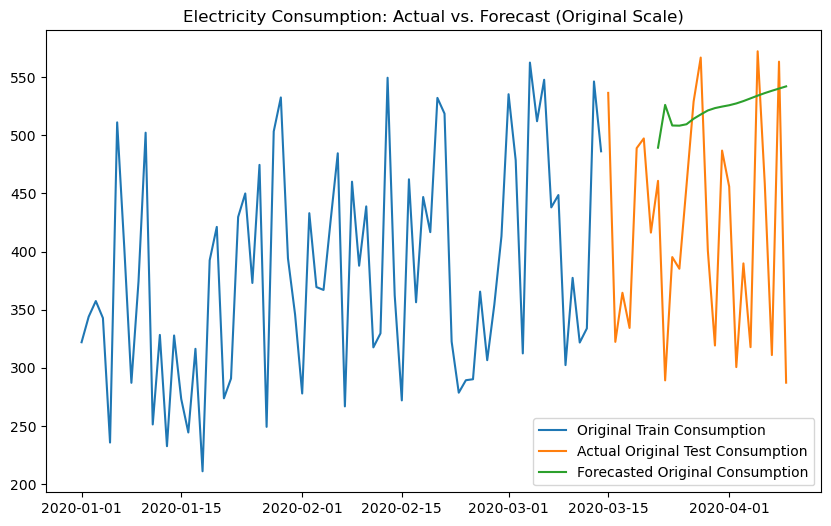

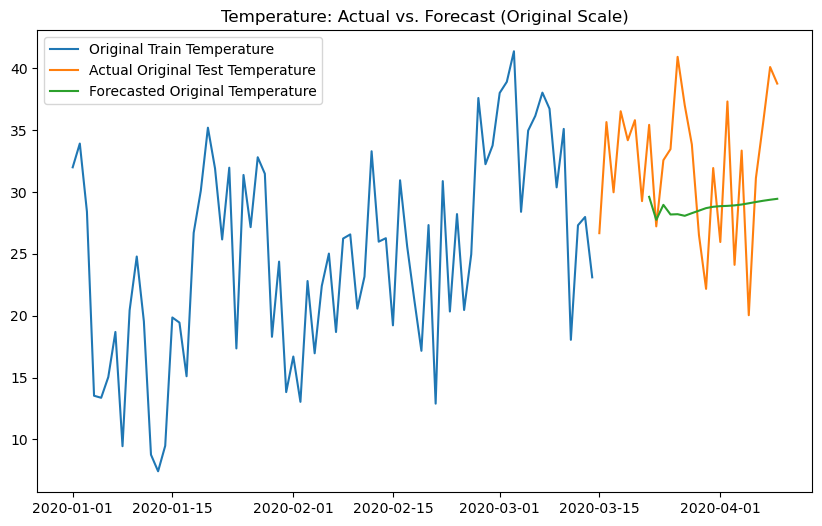

In [42]:
# Inverse Differencing (if applicable): If differencing was applied, convert the forecasts back to the original scale for interpretation.
# For a single differencing (d=1), the inverse is a cumulative sum
# To get the original scale, we need the last value from the original train data
last_train_consumption = data['Consumption'].iloc[train_size - 1]
last_train_temperature = data['Temperature'].iloc[train_size - 1]

# Inverse transform the forecasted differenced values
forecast_original_scale_cons = last_train_consumption + forecast['Consumption'].cumsum()
forecast_original_scale_temp = last_train_temperature + forecast['Temperature'].cumsum()

# Create a DataFrame for the original scale forecasts
forecast_original_scale = pd.DataFrame({
    'Consumption': forecast_original_scale_cons,
    'Temperature': forecast_original_scale_temp
}, index=forecast.index)

# Plot original scale data and forecasts
plt.figure(figsize=(10, 6))
plt.plot(data['Consumption'][:train_size].index, data['Consumption'][:train_size], label='Original Train Consumption')
plt.plot(data['Consumption'][train_size:].index, data['Consumption'][train_size:], label='Actual Original Test Consumption')
plt.plot(forecast_original_scale.index, forecast_original_scale['Consumption'], label='Forecasted Original Consumption')
plt.title('Electricity Consumption: Actual vs. Forecast (Original Scale)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(data['Temperature'][:train_size].index, data['Temperature'][:train_size], label='Original Train Temperature')
plt.plot(data['Temperature'][train_size:].index, data['Temperature'][train_size:], label='Actual Original Test Temperature')
plt.plot(forecast_original_scale.index, forecast_original_scale['Temperature'], label='Forecasted Original Temperature')
plt.title('Temperature: Actual vs. Forecast (Original Scale)')
plt.legend()
plt.show()


# 5. Building the VARMA model (if stationary)

In [43]:
rmse_cons = np.sqrt(mean_squared_error(data['Consumption'][train_size:], forecast_original_scale['Consumption']))
rmse_temp = np.sqrt(mean_squared_error(data['Temperature'][train_size:], forecast_original_scale['Temperature']))

print(f"RMSE for Electricity Consumption: {rmse_cons:.3f}")
print(f"RMSE for Temperature: {rmse_temp:.3f}")


ValueError: Found input variables with inconsistent numbers of samples: [26, 19]